# Game Recomendations on Steam Platform 

Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import MinMaxScaler

DataFiles

In [2]:
# Read the data from files
path = '/Users/manju/Desktop/Data'
df_games = pd.read_csv(path+"/games.csv")
df_users = pd.read_csv(path+"/users.csv")
df_recommendations = pd.read_csv(path+"/recommendations.csv")
df_genre = pd.read_json(path+'/games_metadata.json', lines=True)

Overview

In [3]:
df_games.head(10)

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True
5,250180,METAL SLUG 3,2015-09-14,True,False,False,Very Positive,90,5579,7.99,7.99,0.0,True
6,253980,Enclave,2013-10-04,True,True,True,Mostly Positive,75,1608,4.99,4.99,0.0,True
7,271850,Men of War: Assault Squad 2 - Deluxe Edition u...,2014-05-16,True,False,False,Mixed,61,199,6.99,6.99,0.0,True
8,282900,Hyperdimension Neptunia Re;Birth1,2015-01-29,True,False,False,Very Positive,94,9686,14.99,14.99,0.0,True
9,19810,The Sum of All Fears,2008-10-10,True,False,False,Mostly Positive,75,33,9.99,9.99,0.0,True


In [4]:
'''import pandas as pd

# 1) Ensure your column is a datetime dtype
df_games['date'] = pd.to_datetime(df_games['date_release'])

# method A: by year
df_after2020 = df_games[df_games['date'].dt.year > 2019]'''




"import pandas as pd\n\n# 1) Ensure your column is a datetime dtype\ndf_games['date'] = pd.to_datetime(df_games['date_release'])\n\n# method A: by year\ndf_after2020 = df_games[df_games['date'].dt.year > 2019]"

In [5]:
df_users.head(10)

,user_id,products,reviews
0,7360263,359,0
1,14020781,156,1
2,8762579,329,4
3,4820647,176,4
4,5167327,98,2
5,5664667,145,5
6,5889167,447,2
7,7281762,1083,1
8,7445952,273,1
9,7462927,51,1


In [6]:
df_recommendations.head(10)

,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
0,975370,0,0,2022-12-12,True,36.3,51580,0
1,304390,4,0,2017-02-17,False,11.5,2586,1
2,1085660,2,0,2019-11-17,True,336.5,253880,2
3,703080,0,0,2022-09-23,True,27.4,259432,3
4,526870,0,0,2021-01-10,True,7.9,23869,4
5,306130,0,0,2021-10-10,True,8.6,45425,5
6,238960,0,0,2017-11-25,True,538.8,88282,6
7,730,0,0,2021-11-30,False,157.5,63209,7
8,255710,0,0,2021-05-21,True,18.7,354512,8
9,289070,0,0,2020-05-26,True,397.5,454422,9


In [7]:
df_genre.head(10)

,app_id,description,tags
0,13500,Enter the dark underworld of Prince of Persia ...,"[Action, Adventure, Parkour, Third Person, Gre..."
1,22364,,[Action]
2,113020,Monaco: What's Yours Is Mine is a single playe...,"[Co-op, Stealth, Indie, Heist, Local Co-Op, St..."
3,226560,Escape Dead Island is a Survival-Mystery adven...,"[Zombies, Adventure, Survival, Action, Third P..."
4,249050,Dungeon of the Endless is a Rogue-Like Dungeon...,"[Roguelike, Strategy, Tower Defense, Pixel Gra..."
5,250180,"“METAL SLUG 3”, the masterpiece in SNK’s emble...","[Arcade, Classic, Action, Co-op, Side Scroller..."
6,253980,Experience incredibly atmospheric and intense ...,"[RPG, Action, Fantasy, Third Person, Hack and ..."
7,271850,,"[Strategy, Simulation, Action, RTS, World War II]"
8,282900,"Packed with fast-paced, turn-based RPG action,...","[Anime, JRPG, Female Protagonist, Cute, RPG, S..."
9,19810,Lead a team of domestic counter-terrorism expe...,"[Action, Tactical]"


In [8]:
#Metadata of Dataframes
df_list = [
    ("df_games", df_games),
    ("df_users", df_users),
    ("df_recommendations", df_recommendations),
    ("df_genre", df_genre)
]

for name, df in df_list:
    print(f"\n📄 DataFrame: {name}")
    df.info()


📄 DataFrame: df_games
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50872 entries, 0 to 50871
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   app_id          50872 non-null  int64  
 1   title           50872 non-null  object 
 2   date_release    50872 non-null  object 
 3   win             50872 non-null  bool   
 4   mac             50872 non-null  bool   
 5   linux           50872 non-null  bool   
 6   rating          50872 non-null  object 
 7   positive_ratio  50872 non-null  int64  
 8   user_reviews    50872 non-null  int64  
 9   price_final     50872 non-null  float64
 10  price_original  50872 non-null  float64
 11  discount        50872 non-null  float64
 12  steam_deck      50872 non-null  bool   
dtypes: bool(4), float64(3), int64(3), object(3)
memory usage: 3.7+ MB

📄 DataFrame: df_users
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14306064 entries, 0 to 14306063
Data columns (tot

In [9]:
# Converting all object columns to string dtype
df_games = df_games.astype({col: 'string' for col in df_games.select_dtypes(include='object').columns})
df_genre = df_genre.astype({col: 'string' for col in df_genre.select_dtypes(include='object').columns})

# Converting the date related columns to date dtype
df_games['date_release'] = pd.to_datetime(df_games['date_release'])
df_recommendations['date'] = pd.to_datetime(df_recommendations['date'])

In [10]:
#Metadata of Dataframes after datatype conversions
df_list = [
    ("df_games", df_games),
    ("df_users", df_users),
    ("df_recommendations", df_recommendations),
    ("df_genre", df_genre)
]

for name, df in df_list:
    print(f"\n📄 DataFrame: {name}")
    df.info()


📄 DataFrame: df_games
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50872 entries, 0 to 50871
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   app_id          50872 non-null  int64         
 1   title           50872 non-null  string        
 2   date_release    50872 non-null  datetime64[ns]
 3   win             50872 non-null  bool          
 4   mac             50872 non-null  bool          
 5   linux           50872 non-null  bool          
 6   rating          50872 non-null  string        
 7   positive_ratio  50872 non-null  int64         
 8   user_reviews    50872 non-null  int64         
 9   price_final     50872 non-null  float64       
 10  price_original  50872 non-null  float64       
 11  discount        50872 non-null  float64       
 12  steam_deck      50872 non-null  bool          
dtypes: bool(4), datetime64[ns](1), float64(3), int64(3), string(2)
memory usage: 3.7 MB

In [11]:
for name, df in df_list:
    print(f"Total No. of records in \n📄 DataFrame: {name}")
    print(df.shape[0])

Total No. of records in 
📄 DataFrame: df_games
50872
Total No. of records in 
📄 DataFrame: df_users
14306064
Total No. of records in 
📄 DataFrame: df_recommendations
41154794
Total No. of records in 
📄 DataFrame: df_genre
50872


In [12]:
#Checking for Null Values
for name, df in df_list:
    print(f"\n📄 DataFrame Null Values: {name}")
    print(df.isna().sum())


📄 DataFrame Null Values: df_games
app_id            0
title             0
date_release      0
win               0
mac               0
linux             0
rating            0
positive_ratio    0
user_reviews      0
price_final       0
price_original    0
discount          0
steam_deck        0
dtype: int64

📄 DataFrame Null Values: df_users
user_id     0
products    0
reviews     0
dtype: int64

📄 DataFrame Null Values: df_recommendations
app_id            0
helpful           0
funny             0
date              0
is_recommended    0
hours             0
user_id           0
review_id         0
dtype: int64

📄 DataFrame Null Values: df_genre
app_id         0
description    0
tags           0
dtype: int64


In [13]:
#Checking for 'app_id' Duplicate Values in all dataframes
for name, df in df_list:
    if 'app_id' in df:
        print(f'Total records count in {name} 📄: ',df.shape[0])
        print(f'Distinct app_id records in {name} 📄: ',df['app_id'].nunique())
        
#Checking for 'user_id' Duplicate Values in df_users
print(f'Total records count in df_users 📄: ',df_users.shape[0])
print(f'Distinct user_id records in df_users 📄: ',df_users['user_id'].nunique()) 

#Checking for duplicated based on combination of app_id & their description
print(f'Total duplicate records count in df_games 📄: ',df_games.duplicated(subset=['app_id', 'title']).sum())
print(f'Total duplicate records count in df_genre 📄: ',df_genre.duplicated(subset=['app_id','description']).sum())     
        

Total records count in df_games 📄:  50872
Distinct app_id records in df_games 📄:  50872
Total records count in df_recommendations 📄:  41154794
Distinct app_id records in df_recommendations 📄:  37610
Total records count in df_genre 📄:  50872
Distinct app_id records in df_genre 📄:  50872
Total records count in df_users 📄:  14306064
Distinct user_id records in df_users 📄:  14306064
Total duplicate records count in df_games 📄:  0
Total duplicate records count in df_genre 📄:  0


Data Preprocessing

In [14]:
#Focusing only on the games available on macos
counts = df_games['mac'].value_counts()
print(counts)

mac
False    37854
True     13018
Name: count, dtype: int64


In [15]:
df_games_processed = df_games.copy()
df_games_processed = df_games_processed[df_games_processed['mac'] == True]

In [16]:
df_games_processed

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True
6,253980,Enclave,2013-10-04,True,True,True,Mostly Positive,75,1608,4.99,4.99,0.0,True
13,29180,Osmos,2009-08-18,True,True,True,Very Positive,88,532,9.99,9.99,0.0,True
18,245950,Borderlands 2: Headhunter 4: Wedding Day Massacre,2014-02-11,True,True,True,Very Positive,84,294,0.89,2.99,70.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50830,2195430,Two Point Campus: Medical School,2023-08-17,True,True,True,Mixed,50,22,10.00,0.00,0.0,True
50835,2446110,Stacklands: Cursed Worlds,2023-07-25,True,True,False,Very Positive,90,62,4.00,0.00,0.0,True
50848,2515460,Northgard - Kernev Clan of the Stoat,2023-08-24,True,True,True,Mixed,67,80,5.00,0.00,0.0,True
50851,1555150,Pocket Bravery,2023-08-31,True,True,True,Very Positive,89,248,20.00,0.00,0.0,True


In [17]:
#Considering only the past 5 years games
df_games_sub = df_games_processed.copy()
df_games_sub['date'] = pd.to_datetime(df_games_sub['date_release'])
df_games_sub = df_games_sub[df_games_sub['date'].dt.year > 2019]

In [18]:
df_games_sub.drop(columns=['win', 'mac','linux','steam_deck','positive_ratio', 'discount', 'price_original', 'date'], inplace=True)

In [19]:

# Define custom order from worst to best (if reversed)
order = ["Overwhelmingly Positive", "Very Positive", "Positive", "Mostly Positive",
         "Mixed", "Mostly Negative", "Negative", "Very Negative", "Overwhelmingly Negative"][::-1]

# Initialize encoder with the custom order
enc = OrdinalEncoder(categories=[order])

# Transform the 'rating' column to ordinal values
df_games_sub[['rating']] = enc.fit_transform(df_games_sub[['rating']])

In [20]:
df_games_sub

,app_id,title,date_release,rating,user_reviews,price_final
32,1872790,Luckitown,2022-01-19,7.0,163,4.99
39,1259750,Tropico 6 - Spitter,2020-04-23,4.0,36,9.99
143,498310,RPG in a Box,2022-05-10,7.0,153,29.99
171,672630,Academia : School Simulator,2021-01-28,7.0,2170,19.99
253,914890,Nine Noir Lives,2022-09-07,6.0,39,19.99
...,...,...,...,...,...,...
50830,2195430,Two Point Campus: Medical School,2023-08-17,4.0,22,10.00
50835,2446110,Stacklands: Cursed Worlds,2023-07-25,7.0,62,4.00
50848,2515460,Northgard - Kernev Clan of the Stoat,2023-08-24,4.0,80,5.00
50851,1555150,Pocket Bravery,2023-08-31,7.0,248,20.00


In [21]:
# Choose the numeric columns to normalize
numeric_cols = ['rating', 'user_reviews', 'price_final']

# Fit scaler and transform
scaler = MinMaxScaler()
df_games_sub[numeric_cols] = scaler.fit_transform(df_games_sub[numeric_cols])

In [22]:
games_processed = pd.merge(df_games_sub, df_genre[['app_id', 'tags']], on='app_id', how='inner')

In [23]:
games_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4298 entries, 0 to 4297
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   app_id        4298 non-null   int64         
 1   title         4298 non-null   string        
 2   date_release  4298 non-null   datetime64[ns]
 3   rating        4298 non-null   float64       
 4   user_reviews  4298 non-null   float64       
 5   price_final   4298 non-null   float64       
 6   tags          4298 non-null   string        
dtypes: datetime64[ns](1), float64(3), int64(1), string(2)
memory usage: 235.2 KB


In [24]:
games_processed

,app_id,title,date_release,rating,user_reviews,price_final,tags
0,1872790,Luckitown,2022-01-19,0.875,0.000567,0.024951,"['Simulation', 'Tower Defense', 'Strategy', 'T..."
1,1259750,Tropico 6 - Spitter,2020-04-23,0.500,0.000096,0.049952,"['Simulation', 'Strategy']"
2,498310,RPG in a Box,2022-05-10,0.875,0.000530,0.149957,"['Game Development', 'Animation & Modeling', '..."
3,672630,Academia : School Simulator,2021-01-28,0.875,0.008005,0.099955,"['Management', 'City Builder', 'Base Building'..."
4,914890,Nine Noir Lives,2022-09-07,0.750,0.000107,0.099955,"['Point & Click', 'Comedy', '2D', 'Noir', 'Cut..."
...,...,...,...,...,...,...,...
4293,2195430,Two Point Campus: Medical School,2023-08-17,0.500,0.000044,0.050003,[]
4294,2446110,Stacklands: Cursed Worlds,2023-07-25,0.875,0.000193,0.020001,"['Simulation', 'Indie', 'Casual', 'Survival', ..."
4295,2515460,Northgard - Kernev Clan of the Stoat,2023-08-24,0.500,0.000259,0.025001,"['Strategy', 'Indie', 'Simulation']"
4296,1555150,Pocket Bravery,2023-08-31,0.875,0.000882,0.100005,[]


In [25]:
games_processed = (
    games_processed
      .dropna(subset=['tags'])                  # remove NaNs in tags
      [ games_processed['tags'].map(len) > 2 ]  # then remove empty lists
)

In [26]:
games_processed

,app_id,title,date_release,rating,user_reviews,price_final,tags
0,1872790,Luckitown,2022-01-19,0.875,0.000567,0.024951,"['Simulation', 'Tower Defense', 'Strategy', 'T..."
1,1259750,Tropico 6 - Spitter,2020-04-23,0.500,0.000096,0.049952,"['Simulation', 'Strategy']"
2,498310,RPG in a Box,2022-05-10,0.875,0.000530,0.149957,"['Game Development', 'Animation & Modeling', '..."
3,672630,Academia : School Simulator,2021-01-28,0.875,0.008005,0.099955,"['Management', 'City Builder', 'Base Building'..."
4,914890,Nine Noir Lives,2022-09-07,0.750,0.000107,0.099955,"['Point & Click', 'Comedy', '2D', 'Noir', 'Cut..."
...,...,...,...,...,...,...,...
4288,1410330,Love Shore,2023-06-30,0.500,0.000096,0.074954,"['Cyberpunk', 'RPG', 'Choices Matter', 'Noir',..."
4289,2159650,Drift,2023-05-12,0.500,0.000096,0.079954,"['Open World Survival Craft', 'Survival', 'Onl..."
4291,2349040,Dinky Guardians,2023-10-02,0.750,0.000022,0.065003,"['Automation', 'Simulation', 'Co-op', 'Colony ..."
4294,2446110,Stacklands: Cursed Worlds,2023-07-25,0.875,0.000193,0.020001,"['Simulation', 'Indie', 'Casual', 'Survival', ..."


In [27]:
common_game_ids = games_processed['app_id'].unique()
recommendations = df_recommendations[df_recommendations['app_id'].isin(common_game_ids)].copy()

In [28]:
recommendations.count()

app_id            1279263
helpful           1279263
funny             1279263
date              1279263
is_recommended    1279263
hours             1279263
user_id           1279263
review_id         1279263
dtype: int64

In [29]:
recommendations

,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
73932,1218210,8,0,2022-07-13,True,119.5,4159892,73932
76525,1218210,6,0,2022-04-09,True,24.3,9824132,76525
132577,1218210,14,0,2022-04-01,True,11.7,11311605,132577
254185,1218210,2,0,2022-06-30,True,32.7,3830708,254185
300086,1218210,123,36,2022-04-04,False,32.5,11545696,300086
...,...,...,...,...,...,...,...,...
41154745,1104450,0,0,2020-07-29,True,3.0,9985656,41154745
41154746,893850,0,0,2020-09-14,True,128.0,821144,41154746
41154748,1404850,0,0,2021-04-15,True,8.0,11065427,41154748
41154769,1138660,0,0,2021-08-13,False,11.0,10433531,41154769


In [30]:
#Droping the review_id column & coverting booolean to numeric
recommendations.drop(columns=['review_id'], inplace=True)
recommendations['is_recommended'] = recommendations['is_recommended'].astype(int)

In [31]:
recommendations

,app_id,helpful,funny,date,is_recommended,hours,user_id
73932,1218210,8,0,2022-07-13,1,119.5,4159892
76525,1218210,6,0,2022-04-09,1,24.3,9824132
132577,1218210,14,0,2022-04-01,1,11.7,11311605
254185,1218210,2,0,2022-06-30,1,32.7,3830708
300086,1218210,123,36,2022-04-04,0,32.5,11545696
...,...,...,...,...,...,...,...
41154745,1104450,0,0,2020-07-29,1,3.0,9985656
41154746,893850,0,0,2020-09-14,1,128.0,821144
41154748,1404850,0,0,2021-04-15,1,8.0,11065427
41154769,1138660,0,0,2021-08-13,0,11.0,10433531


In [32]:
count = (recommendations['hours'] < 2).sum()
count

np.int64(222962)

In [33]:
recommendations_df = recommendations[recommendations['hours'] > 2].copy()

In [34]:
recommendations_df

,app_id,helpful,funny,date,is_recommended,hours,user_id
73932,1218210,8,0,2022-07-13,1,119.5,4159892
76525,1218210,6,0,2022-04-09,1,24.3,9824132
132577,1218210,14,0,2022-04-01,1,11.7,11311605
254185,1218210,2,0,2022-06-30,1,32.7,3830708
300086,1218210,123,36,2022-04-04,0,32.5,11545696
...,...,...,...,...,...,...,...
41154745,1104450,0,0,2020-07-29,1,3.0,9985656
41154746,893850,0,0,2020-09-14,1,128.0,821144
41154748,1404850,0,0,2021-04-15,1,8.0,11065427
41154769,1138660,0,0,2021-08-13,0,11.0,10433531


In [35]:
#Compute max hours_played per user
user_max_hours = recommendations_df.groupby('user_id')['hours'].max().reset_index()
user_max_hours.rename(columns={'hours': 'max_hours'}, inplace=True)

# Merge with original DataFrame
recommendations_df = recommendations_df.merge(user_max_hours, on='user_id')

#Compute implicit rating
recommendations_df['rating'] = recommendations_df['hours'] / recommendations_df['max_hours']

In [36]:
recommendations_df

,app_id,helpful,funny,date,is_recommended,hours,user_id,max_hours,rating
0,1218210,8,0,2022-07-13,1,119.5,4159892,119.5,1.000000
1,1218210,6,0,2022-04-09,1,24.3,9824132,32.7,0.743119
2,1218210,14,0,2022-04-01,1,11.7,11311605,33.2,0.352410
3,1218210,2,0,2022-06-30,1,32.7,3830708,32.7,1.000000
4,1218210,123,36,2022-04-04,0,32.5,11545696,35.6,0.912921
...,...,...,...,...,...,...,...,...,...
1034565,1104450,0,0,2020-07-29,1,3.0,9985656,3.0,1.000000
1034566,893850,0,0,2020-09-14,1,128.0,821144,128.0,1.000000
1034567,1404850,0,0,2021-04-15,1,8.0,11065427,8.0,1.000000
1034568,1138660,0,0,2021-08-13,0,11.0,10433531,25.0,0.440000


In [37]:
recommendations_df.drop(columns=['max_hours'], inplace=True)

In [38]:
recommendations_df

,app_id,helpful,funny,date,is_recommended,hours,user_id,rating
0,1218210,8,0,2022-07-13,1,119.5,4159892,1.000000
1,1218210,6,0,2022-04-09,1,24.3,9824132,0.743119
2,1218210,14,0,2022-04-01,1,11.7,11311605,0.352410
3,1218210,2,0,2022-06-30,1,32.7,3830708,1.000000
4,1218210,123,36,2022-04-04,0,32.5,11545696,0.912921
...,...,...,...,...,...,...,...,...
1034565,1104450,0,0,2020-07-29,1,3.0,9985656,1.000000
1034566,893850,0,0,2020-09-14,1,128.0,821144,1.000000
1034567,1404850,0,0,2021-04-15,1,8.0,11065427,1.000000
1034568,1138660,0,0,2021-08-13,0,11.0,10433531,0.440000


In [39]:
# Choose the numeric columns to normalize
numeric_cols = ['helpful', 'funny', 'hours']

# Fit scaler and transform
scaler = MinMaxScaler()
recommendations_df[numeric_cols] = scaler.fit_transform(recommendations_df[numeric_cols])

In [40]:
recommendations_df

,app_id,helpful,funny,date,is_recommended,hours,user_id,rating
0,1218210,0.000410,0.000000,2022-07-13,1,0.117647,4159892,1.000000
1,1218210,0.000307,0.000000,2022-04-09,1,0.022247,9824132,0.743119
2,1218210,0.000717,0.000000,2022-04-01,1,0.009620,11311605,0.352410
3,1218210,0.000102,0.000000,2022-06-30,1,0.030664,3830708,1.000000
4,1218210,0.006297,0.004308,2022-04-04,0,0.030464,11545696,0.912921
...,...,...,...,...,...,...,...,...
1034565,1104450,0.000000,0.000000,2020-07-29,1,0.000902,9985656,1.000000
1034566,893850,0.000000,0.000000,2020-09-14,1,0.126165,821144,1.000000
1034567,1404850,0.000000,0.000000,2021-04-15,1,0.005912,11065427,1.000000
1034568,1138660,0.000000,0.000000,2021-08-13,0,0.008919,10433531,0.440000


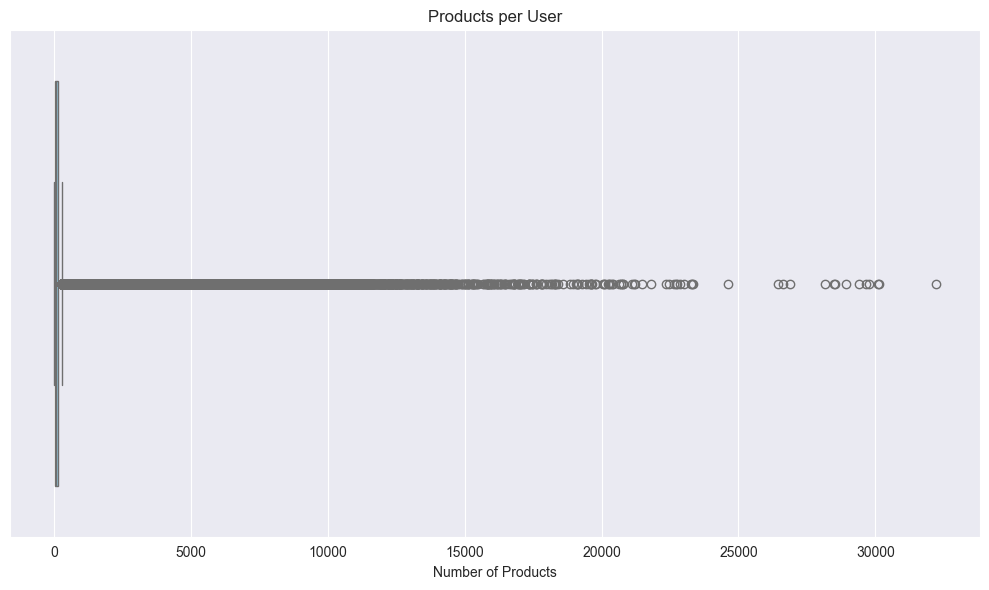

In [41]:
users = df_users.copy()
plt.figure(figsize=(10, 6))
sns.boxplot(x='products', data=users, color='skyblue')
plt.title('Products per User')
plt.xlabel('Number of Products')
plt.tight_layout()
plt.show()

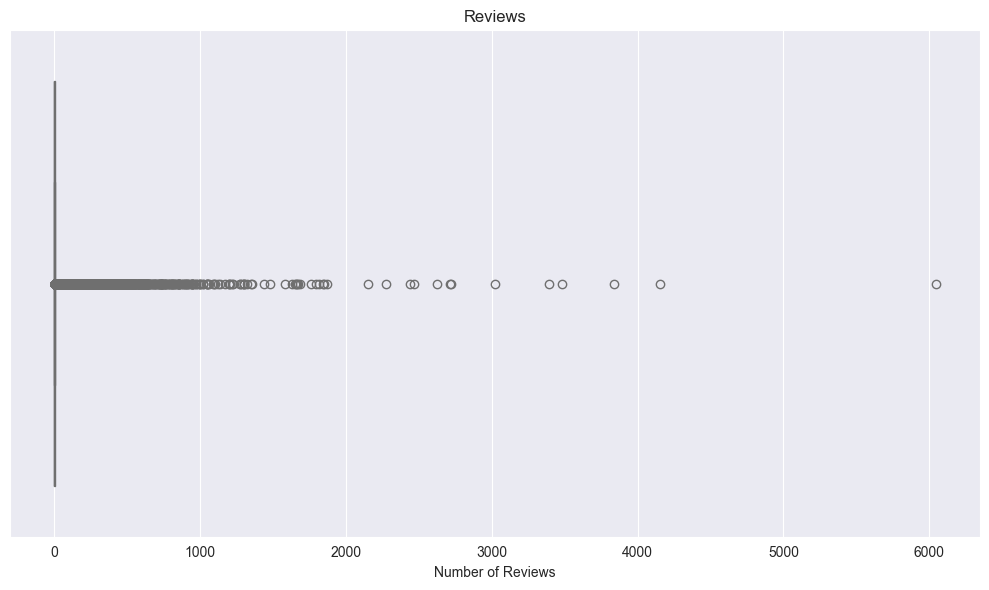

In [42]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='reviews', data=users, color='skyblue')
plt.title('Reviews')
plt.xlabel('Number of Reviews')
plt.tight_layout()
plt.show()

In [43]:
# Choose the numeric columns to normalize
numeric_cols = ['products', 'reviews']

# Fit scaler and transform
scaler = MinMaxScaler()
df_users[numeric_cols] = scaler.fit_transform(df_users[numeric_cols])

In [44]:
df_users

,user_id,products,reviews
0,7360263,0.011144,0.000000
1,14020781,0.004843,0.000165
2,8762579,0.010213,0.000662
3,4820647,0.005463,0.000662
4,5167327,0.003042,0.000331
...,...,...,...
14306059,5047430,0.000186,0.000000
14306060,5048153,0.000000,0.000000
14306061,5059205,0.000962,0.000000
14306062,5074363,0.000000,0.000000


# Embedded based Recommendations system

In [45]:
recommendations_df.rename(columns={'rating': 'hours_rating'}, inplace=True)


In [46]:
recommendations_df

,app_id,helpful,funny,date,is_recommended,hours,user_id,hours_rating
0,1218210,0.000410,0.000000,2022-07-13,1,0.117647,4159892,1.000000
1,1218210,0.000307,0.000000,2022-04-09,1,0.022247,9824132,0.743119
2,1218210,0.000717,0.000000,2022-04-01,1,0.009620,11311605,0.352410
3,1218210,0.000102,0.000000,2022-06-30,1,0.030664,3830708,1.000000
4,1218210,0.006297,0.004308,2022-04-04,0,0.030464,11545696,0.912921
...,...,...,...,...,...,...,...,...
1034565,1104450,0.000000,0.000000,2020-07-29,1,0.000902,9985656,1.000000
1034566,893850,0.000000,0.000000,2020-09-14,1,0.126165,821144,1.000000
1034567,1404850,0.000000,0.000000,2021-04-15,1,0.005912,11065427,1.000000
1034568,1138660,0.000000,0.000000,2021-08-13,0,0.008919,10433531,0.440000


In [47]:
'''#Merge both the dataframes
games_processed_df.set_index('app_id', inplace=True)
recommendations_df = recommendations_df.join(games_processed_df, on='app_id', how='inner')'''


"#Merge both the dataframes\ngames_processed_df.set_index('app_id', inplace=True)\nrecommendations_df = recommendations_df.join(games_processed_df, on='app_id', how='inner')"

In [48]:
recommendations_df

,app_id,helpful,funny,date,is_recommended,hours,user_id,hours_rating
0,1218210,0.000410,0.000000,2022-07-13,1,0.117647,4159892,1.000000
1,1218210,0.000307,0.000000,2022-04-09,1,0.022247,9824132,0.743119
2,1218210,0.000717,0.000000,2022-04-01,1,0.009620,11311605,0.352410
3,1218210,0.000102,0.000000,2022-06-30,1,0.030664,3830708,1.000000
4,1218210,0.006297,0.004308,2022-04-04,0,0.030464,11545696,0.912921
...,...,...,...,...,...,...,...,...
1034565,1104450,0.000000,0.000000,2020-07-29,1,0.000902,9985656,1.000000
1034566,893850,0.000000,0.000000,2020-09-14,1,0.126165,821144,1.000000
1034567,1404850,0.000000,0.000000,2021-04-15,1,0.005912,11065427,1.000000
1034568,1138660,0.000000,0.000000,2021-08-13,0,0.008919,10433531,0.440000


In [49]:
def create_cold_start_split(recommendations_df, test_size=0.15, val_size=0.15,
                            timestamp_col='date', cold_start_user_frac=0.01, seed=42):
    import numpy as np
    np.random.seed(seed)

    # Sort by timestamp if available
    if timestamp_col in recommendations_df.columns:
        recommendations_df = recommendations_df.sort_values(timestamp_col)

    # Identify cold-start users and items
    all_users = recommendations_df['user_id'].unique()
    all_items = recommendations_df['app_id'].unique()

    n_cold_users = int(len(all_users) * cold_start_user_frac)


    cold_users = np.random.choice(all_users, size=n_cold_users, replace=False)


    # Cold-start test data
    cold_user_df = recommendations_df[recommendations_df['user_id'].isin(cold_users)]


    # Remove cold users/items from the remaining dataset
    warm_df = recommendations_df[
        ~recommendations_df['user_id'].isin(cold_users)
    ]

    # Now split warm_df by user chronologically
    user_groups = warm_df.groupby('user_id')

    train_data = []
    val_data = []
    test_data = []

    for user_id, user_data in user_groups:
        n = len(user_data)
        if n < 3:
            continue

        n_test = max(1, int(n * test_size))
        n_val = max(1, int(n * val_size))

        user_train = user_data.iloc[:-n_test-n_val]
        user_val = user_data.iloc[-n_test-n_val:-n_test]
        user_test = user_data.iloc[-n_test:]

        train_data.append(user_train)
        val_data.append(user_val)
        test_data.append(user_test)

    train_df = pd.concat(train_data)
    val_df = pd.concat(val_data)
    test_df = pd.concat(test_data)

    return train_df, val_df, test_df, cold_user_df


train_df, val_df, test_df, cold_user_df = create_cold_start_split(recommendations_df)

print(f"Train Set: {len(train_df)} Recommendations")
print(f"Validation Set: {len(val_df)} Recommendations")
print(f"Test Set: {len(test_df)} Recommendations")
print(f"Cold-Start Test Set: {len(cold_user_df)} Users")

Train Set: 77464 Recommendations
Validation Set: 35794 Recommendations
Test Set: 35794 Recommendations
Cold-Start Test Set: 10446 Users


In [50]:
import pandas as pd

all_user_idx = (
    pd.Index(recommendations_df.user_id)
)
all_user_ids = all_user_idx.unique().to_numpy()

all_game_idx = (
    pd.Index(train_df.app_id)
      .union(val_df.app_id)
      .union(test_df.app_id)
      .union(games_processed.app_id)
)
all_game_ids = all_game_idx.unique().to_numpy()

In [51]:
from ast import literal_eval
from lightfm.data import Dataset

# Make sure tags are real lists, not strings:
games_processed['tags'] = games_processed['tags'].apply(literal_eval)

def item_feats():
    for _, row in games_processed.iterrows():
        tags = row['tags']  # e.g. ['Simulation', 'Strategy', …]

        # build a dict of tag→1.0 plus your numeric features
        feat_dict = {tag: 1.0 for tag in tags}
        feat_dict['price_final'] = row['price_final']
        feat_dict['rating']      = row['rating']

        # **THIS** is critical:
        yield row['app_id'], feat_dict



/Users/manju/PyCharmMiscProject/.venv1/lib/python3.10/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


In [52]:
from lightfm.data import Dataset
from lightfm import LightFM

#fit Dataset on all IDs & features
dataset = Dataset()
dataset.fit(
    users = all_user_ids,
    items = all_game_ids,
    item_features = set(f for tags in games_processed.tags for f in tags)
                  | {'rating','price_final'}, # including the numeric feature names
    user_features = ['hours_rating']
)


In [53]:
#Train interaction matrix
train_interactions, _ = dataset.build_interactions(
    (row.user_id, row.app_id, row.hours_rating)
    for row in train_df.itertuples()
)

In [54]:
item_features = dataset.build_item_features(item_feats(), normalize=False)

In [55]:
# Test Data Interactions
test_interactions, _ = dataset.build_interactions(
    (row['user_id'], row['app_id'], row['hours_rating'])
    for _, row in test_df.iterrows()
)

In [56]:
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 77464, Val: 35794, Test: 35794


In [57]:
from lightfm import LightFM
from lightfm.evaluation import precision_at_k, recall_at_k

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Build interactions for each split
tr_inter, _  = dataset.build_interactions(
    (u, i, r)
    for u, i, r in zip(train_df['user_id'],
                       train_df['app_id'],
                       train_df['hours_rating'])
)
val_inter, _ = dataset.build_interactions(
    (u, i, r)
    for u, i, r in zip(val_df['user_id'],
                       val_df['app_id'],
                       val_df['hours_rating'])
)
test_inter, _ = dataset.build_interactions(
    (u, i, r)
    for u, i, r in zip(test_df['user_id'],
                       test_df['app_id'],
                       test_df['hours_rating'])
)

# Fit on just the train split
model = LightFM(loss='warp', no_components=60, learning_rate=0.05)
model.fit(tr_inter,
          item_features=item_features,
          epochs=10,
          num_threads=4)

# 4. Evaluate on validation
val_p = precision_at_k(model, val_inter,
                       item_features=item_features, k=20).mean()
val_r = recall_at_k(   model, val_inter,
                       item_features=item_features, k=20).mean()
print(f"Validation — Precision@20: {val_p:.4f}, Recall@20: {val_r:.4f}")




Train: 77464, Val: 35794, Test: 35794
Validation — Precision@20: 0.0113, Recall@20: 0.2238


In [58]:
from sklearn.model_selection import train_test_split, ParameterGrid
from lightfm import LightFM
from lightfm.evaluation import precision_at_k, recall_at_k
import numpy as np
import pandas as pd

# hyperparameter grid
param_grid = {
    'no_components':      [30, 60],
    'learning_rate':      [0.01, 0.05, 0.001],
    'item_alpha':         [1e-6, 1e-5],
    'user_alpha':         [1e-6, 1e-5],
    'loss':               ['warp'],  # , 'bpr', 'logistic'
    'learning_schedule':  ['adagrad', 'adadelta'],
    # 'max_sampled':        [10, 20]    # only used by WARP/BPR losses
}

results = []
for params in ParameterGrid(param_grid):
    # instantiate model with this combo
    model = LightFM(
        no_components     = params['no_components'],
        learning_rate     = params['learning_rate'],
        item_alpha        = params['item_alpha'],
        user_alpha        = params['user_alpha'],
        loss              = params['loss'],
        learning_schedule = params['learning_schedule'],
        # max_sampled       = params.get('max_sampled', None)
    )

    # train on the TRAIN split
    model.fit(
        tr_inter,
        item_features = item_features,
        epochs        = 10,
        num_threads   = 8,
        verbose       = False
    )

    # evaluate on the VAL split
    prec_val = precision_at_k(
        model, val_inter,
        item_features = item_features,
        k             = 20,
        num_threads   = 8
    ).mean()

    rec_val  = recall_at_k(
        model, val_inter,
        item_features = item_features,
        k             = 20,
        num_threads   = 8
    ).mean()

    # compute F1 score (harmonic mean of precision and recall)
    if (prec_val + rec_val) > 0:
        f1_val = 2 * (prec_val * rec_val) / (prec_val + rec_val)
    else:
        f1_val = 0.0

    # record results
    results.append({
        **params,
        'prec_val':    prec_val,
        'rec_val':     rec_val,
        'f1_val':      f1_val,
    })

    print(f"Params: {params} | Precision: {prec_val:.4f} | Recall: {rec_val:.4f} | F1: {f1_val:.4f}")

# Tabulate and sort by validation F1 score (or precision)
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('f1_val', ascending=False).reset_index(drop=True)

results_df


Params: {'item_alpha': 1e-06, 'learning_rate': 0.01, 'learning_schedule': 'adagrad', 'loss': 'warp', 'no_components': 30, 'user_alpha': 1e-06} | Precision: 0.0114 | Recall: 0.2260 | F1: 0.0218
Params: {'item_alpha': 1e-06, 'learning_rate': 0.01, 'learning_schedule': 'adagrad', 'loss': 'warp', 'no_components': 30, 'user_alpha': 1e-05} | Precision: 0.0116 | Recall: 0.2287 | F1: 0.0220
Params: {'item_alpha': 1e-06, 'learning_rate': 0.01, 'learning_schedule': 'adagrad', 'loss': 'warp', 'no_components': 60, 'user_alpha': 1e-06} | Precision: 0.0117 | Recall: 0.2312 | F1: 0.0223
Params: {'item_alpha': 1e-06, 'learning_rate': 0.01, 'learning_schedule': 'adagrad', 'loss': 'warp', 'no_components': 60, 'user_alpha': 1e-05} | Precision: 0.0118 | Recall: 0.2327 | F1: 0.0224
Params: {'item_alpha': 1e-06, 'learning_rate': 0.01, 'learning_schedule': 'adadelta', 'loss': 'warp', 'no_components': 30, 'user_alpha': 1e-06} | Precision: 0.0112 | Recall: 0.2214 | F1: 0.0213
Params: {'item_alpha': 1e-06, 'lea

,item_alpha,learning_rate,learning_schedule,loss,no_components,user_alpha,prec_val,rec_val,f1_val
0,0.000010,0.050,adadelta,warp,60,0.000010,0.012374,0.245195,0.023558
1,0.000010,0.001,adadelta,warp,30,0.000010,0.012151,0.240780,0.023135
2,0.000001,0.010,adadelta,warp,60,0.000010,0.012024,0.238189,0.022892
3,0.000001,0.010,adadelta,warp,30,0.000010,0.011972,0.236944,0.022792
4,0.000010,0.001,adadelta,warp,60,0.000001,0.011952,0.236576,0.022754
5,0.000010,0.010,adadelta,warp,60,0.000001,0.011910,0.235876,0.022675
6,0.000010,0.010,adadelta,warp,60,0.000010,0.011897,0.235552,0.022649
7,0.000010,0.050,adadelta,warp,60,0.000001,0.011858,0.234955,0.022576
8,0.000001,0.001,adadelta,warp,60,0.000010,0.011830,0.234515,0.022524
9,0.000001,0.050,adadelta,warp,30,0.000010,0.011830,0.234312,0.022523


In [59]:
# Best Hyperparaneters from Grid Search Method
best = results_df.iloc[0]
best_params = {
    'loss':          'warp',
    'no_components': int(best['no_components']),
    'learning_rate': float(best['learning_rate']),
    'item_alpha':    float(best['item_alpha']),
    'user_alpha':    float(best['user_alpha']),
    'learning_schedule': best['learning_schedule'],
}

print("Final training with:", best_params)

Final training with: {'loss': 'warp', 'no_components': 60, 'learning_rate': 0.05, 'item_alpha': 1e-05, 'user_alpha': 1e-05, 'learning_schedule': 'adadelta'}


In [58]:
import numpy as np
from scipy.stats import loguniform, randint
from sklearn.base import BaseEstimator
from sklearn.model_selection import RandomizedSearchCV
from lightfm import LightFM
from lightfm.evaluation import precision_at_k, recall_at_k

class LightFMEstimator(BaseEstimator):
    def __init__(
        self,
        no_components=30,
        learning_rate=0.05,
        item_alpha=1e-6,
        user_alpha=1e-6,
        loss='warp',
        learning_schedule='adagrad',
        epochs=10,
        k=20,
        num_threads=8,
    ):
        self.no_components = no_components
        self.learning_rate = learning_rate
        self.item_alpha = item_alpha
        self.user_alpha = user_alpha
        self.loss = loss
        self.learning_schedule = learning_schedule
        self.epochs = epochs
        self.k = k
        self.num_threads = num_threads

    def fit(self, X, y=None):
        tr_inter, item_features = X[0] if isinstance(X, (list, np.ndarray)) else X
        self.model_ = LightFM(
            no_components=self.no_components,
            learning_rate=self.learning_rate,
            item_alpha=self.item_alpha,
            user_alpha=self.user_alpha,
            loss=self.loss,
            learning_schedule=self.learning_schedule,
        )
        self.model_.fit(
            tr_inter,
            item_features=item_features,
            epochs=self.epochs,
            num_threads=self.num_threads,
            verbose=False,
        )
        return self

    def score(self, X, y=None):
        val_inter, item_features = X[0] if isinstance(X, (list, np.ndarray)) else X
        prec = precision_at_k(
            self.model_,
            val_inter,
            item_features=item_features,
            k=self.k,
            num_threads=self.num_threads,
        ).mean()
        rec = recall_at_k(
            self.model_,
            val_inter,
            item_features=item_features,
            k=self.k,
            num_threads=self.num_threads,
        ).mean()
        return (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0


# pure‐callable scorers
def precision_scorer(estimator, X, y=None):
    val_inter, item_features = X[0] if isinstance(X, (list, np.ndarray)) else X
    return precision_at_k(
        estimator.model_,
        val_inter,
        item_features=item_features,
        k=estimator.k,
        num_threads=estimator.num_threads,
    ).mean()

def recall_scorer(estimator, X, y=None):
    val_inter, item_features = X[0] if isinstance(X, (list, np.ndarray)) else X
    return recall_at_k(
        estimator.model_,
        val_inter,
        item_features=item_features,
        k=estimator.k,
        num_threads=estimator.num_threads,
    ).mean()

# pack them into a dict of callables
scoring = {
    'f1':       lambda est, X, y=None: est.score(X, y),
    'precision': precision_scorer,
    'recall':    recall_scorer,
}

# --- assume you already have these defined ---
# tr_inter, val_inter, item_features

X = [
    (tr_inter, item_features),  # train
    (val_inter, item_features)  # validation
]
y = [0, 0]  # dummy

param_dist = {
    'no_components':     randint(20, 101),
    'learning_rate':     loguniform(1e-3, 1e-1),
    'item_alpha':        loguniform(1e-7, 1e-3),
    'user_alpha':        loguniform(1e-7, 1e-3),
    'loss':              ['warp'],          # or add 'bpr','logistic'
    'learning_schedule': ['adagrad', 'adadelta'],
    'epochs':            [10, 20, 30],
}

rand_search = RandomizedSearchCV(
    estimator=LightFMEstimator(k=20, num_threads=8),
    param_distributions=param_dist,
    n_iter=30,
    cv=[([0], [1])],    # train on X[0], test on X[1]
    scoring=scoring,
    refit='f1',         # choose best model by F1
    random_state=42,
    verbose=2,
    error_score='raise'
)

rand_search.fit(X, y)

# extract the best‐fold means
best = rand_search.best_index_
cv = rand_search.cv_results_

print("Best F1 score:  ", cv['mean_test_f1'][best])
print("Precision @20:  ", cv['mean_test_precision'][best])
print("Recall  @20:    ", cv['mean_test_recall'][best])
print("Best params:    ", rand_search.best_params_)


Fitting 1 folds for each of 30 candidates, totalling 30 fits
[CV] END epochs=30, item_alpha=0.00015352246941973476, learning_rate=0.002327392228062871, learning_schedule=adadelta, loss=warp, no_components=80, user_alpha=2.4400607090817545e-05; total time= 1.7min
[CV] END epochs=20, item_alpha=4.207053950287931e-07, learning_rate=0.0013066739238053278, learning_schedule=adadelta, loss=warp, no_components=43, user_alpha=4.013783023846253e-05; total time= 1.5min
[CV] END epochs=10, item_alpha=0.0007579479953348002, learning_rate=0.04622589001020832, learning_schedule=adadelta, loss=warp, no_components=21, user_alpha=5.337032762603952e-07; total time=  59.4s
[CV] END epochs=10, item_alpha=2.9507066707905283e-05, learning_rate=0.016722697006183687, learning_schedule=adagrad, loss=warp, no_components=68, user_alpha=1.2563152773938656e-05; total time= 1.4min
[CV] END epochs=30, item_alpha=3.613894271216524e-07, learning_rate=0.00383962929980417, learning_schedule=adadelta, loss=warp, no_compo

In [59]:
import pandas as pd

#full cv_results_ dict
cv_results = rand_search.cv_results_

# Turning it into a DataFrame
LightFMRand_results_df = pd.DataFrame(cv_results)

#Expanding the 'params' dict into its own columns
params_df = LightFMRand_results_df['params'].apply(pd.Series)
'''
#Concatenate parameter columns with the main scoring columns you care about
LightFMRand_results_df = pd.concat([
    params_df,
    LightFMRand_results_df[['mean_test_score', 'std_test_score', 'rank_test_score']]
], axis=1)

#Sort by your primary metric (mean_test_score → F1)
LightFMRand_results_df = LightFMRand_results_df.sort_values('mean_test_score', ascending=False).reset_index(drop=True)

'''

LightFMRand_results_df


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_epochs,param_item_alpha,param_learning_rate,param_learning_schedule,param_loss,param_no_components,...,std_test_f1,rank_test_f1,split0_test_precision,mean_test_precision,std_test_precision,rank_test_precision,split0_test_recall,mean_test_recall,std_test_recall,rank_test_recall
0,21.514611,0.0,80.115797,0.0,30,1.535225e-04,0.002327,adadelta,warp,80,...,0.0,28,0.000689,0.000689,0.0,28,0.013689,0.013689,0.0,28
1,5.458390,0.0,82.335827,0.0,20,4.207054e-07,0.001307,adadelta,warp,43,...,0.0,3,0.011683,0.011683,0.0,3,0.231031,0.231031,0.0,4
2,2.602498,0.0,56.807908,0.0,10,7.579480e-04,0.046226,adadelta,warp,21,...,0.0,29,0.000551,0.000551,0.0,29,0.010942,0.010942,0.0,29
3,3.225642,0.0,78.050499,0.0,10,2.950707e-05,0.016723,adagrad,warp,68,...,0.0,1,0.011889,0.011889,0.0,1,0.234830,0.234830,0.0,1
4,5.565403,0.0,54.995317,0.0,30,3.613894e-07,0.003840,adadelta,warp,34,...,0.0,16,0.010959,0.010959,0.0,16,0.216943,0.216943,0.0,16
5,9.421607,0.0,84.769974,0.0,30,2.975391e-05,0.005820,adadelta,warp,83,...,0.0,6,0.011644,0.011644,0.0,6,0.231169,0.231169,0.0,3
6,2.942816,0.0,65.635468,0.0,10,2.692647e-05,0.002193,adagrad,warp,37,...,0.0,21,0.010090,0.010090,0.0,21,0.199373,0.199373,0.0,21
7,3.560859,0.0,55.518932,0.0,20,1.712338e-04,0.004067,adagrad,warp,21,...,0.0,4,0.011654,0.011654,0.0,4,0.230322,0.230322,0.0,6
8,8.558337,0.0,76.299252,0.0,30,5.408217e-05,0.016596,adadelta,warp,66,...,0.0,19,0.010449,0.010449,0.0,19,0.207338,0.207338,0.0,19
9,3.258585,0.0,75.810387,0.0,10,1.084226e-06,0.021137,adadelta,warp,25,...,0.0,13,0.011179,0.011179,0.0,13,0.221198,0.221198,0.0,13


In [61]:
#Concatenate the train + validation DataFrames
combined_df = pd.concat([train_df, val_df], ignore_index=True)

# Build the sparse interaction matrix
#    (this also handles mapping raw IDs → internal row/col indices)
combined_interactions, _ = dataset.build_interactions(
    (u, i, r)
    for u, i, r in zip(
        combined_df['user_id'],
        combined_df['app_id'],
        combined_df['hours_rating']
    )
)

# Grab the best hyperparameters you found
best = results_df.iloc[0]
best_params = {
    'loss':          'warp',
    'no_components': int(best['no_components']),
    'learning_rate': float(best['learning_rate']),
    'item_alpha':    float(best['item_alpha']),
    'user_alpha':    float(best['user_alpha']),
    'learning_schedule': best['learning_schedule'],
}

print("Final training with:", best_params)

# Initialize and train on the **sparse** interactions matrix
final_model = LightFM(**best_params)
final_model.fit(
    combined_interactions,
    item_features=item_features,   # if you have them
    user_features=None,
    epochs=30,
    num_threads=4
)


Final training with: {'loss': 'warp', 'no_components': 60, 'learning_rate': 0.05, 'item_alpha': 1e-05, 'user_alpha': 1e-05, 'learning_schedule': 'adadelta'}


In [62]:
# Saving the model
import pickle
with open('lightfm_final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("✅  Final model trained and saved.")

✅  Final model trained and saved.


In [ ]:
'''For all the models'''

from tqdm import tqdm
from lightfm.evaluation import precision_at_k, recall_at_k, auc_score
from numba import njit, prange
import numpy as np
import pandas as pd

# ——— JIT nDCG helpers ———
def get_weights(K):
    """
    Returns:
      weights         : array of 1/log2(i+2) for i=0..K-1
      cumsum_weights  : cumulative sum of weights (for IDCG)
    """
    w = 1.0 / np.log2(np.arange(2, K + 2))
    return w, np.cumsum(w)

@njit(parallel=True, fastmath=True)
def compute_ndcgs(ranks, true_mat_bool, weights, cumsum_weights, true_counts, K):
    """
    ranks            : (n_users, K) int32  — top-K item indices per user
    true_mat_bool    : (n_users, n_items)  bool
    weights          : (K,)       float64 — DCG weights
    cumsum_weights   : (K,)       float64 — prefix sums of weights
    true_counts      : (n_users,) int32   — # of positives per user
    K                : int
    """
    n_users = ranks.shape[0]
    ndcgs = np.empty(n_users, dtype=np.float64)

    for u in prange(n_users):
        dcg = 0.0
        # DCG@K
        for i in range(K):
            if true_mat_bool[u, ranks[u, i]]:
                dcg += weights[i]
        # IDCG@K
        t = true_counts[u]
        if t > 0:
            ideal = t if t < K else K
            idcg = cumsum_weights[ideal - 1]
            ndcgs[u] = dcg / idcg
        else:
            ndcgs[u] = 0.0

    return ndcgs

# ——— Build test interactions ———
test_interactions, _ = dataset.build_interactions(
    (u, i, r)
    for u, i, r in zip(
        test_df['user_id'],
        test_df['app_id'],
        test_df['hours_rating']
    )
)

n_users, n_items = test_interactions.shape
all_items = np.arange(n_items)
Ks = [5, 10, 20]
results = []

# True‐relevance matrix
true_mat      = test_interactions.tocsr().toarray()
true_mat_bool = true_mat > 0
true_counts   = true_mat_bool.sum(axis=1).astype(np.int32)

# Precompute all scores
scores_mat = np.vstack([
    final_model.predict(u, all_items, item_features=item_features)
    for u in tqdm(range(n_users), desc='Scoring all users')
])

# ——— Evaluation loop ———
for K in tqdm(Ks, desc='Evaluating @K'):
    # 1) Precision & Recall
    prec = precision_at_k(
        final_model,
        test_interactions,
        item_features=item_features,
        k=K,
    ).mean()
    rec = recall_at_k(
        final_model,
        test_interactions,
        item_features=item_features,
        k=K,
    ).mean()

    # 2) Fast top‑K partial sort + exact sort
    topk_part   = np.argpartition(-scores_mat, K-1, axis=1)[:, :K]
    topk_scores = np.take_along_axis(scores_mat, topk_part, axis=1)
    idx_sort    = np.argsort(-topk_scores, axis=1)
    ranks       = np.take_along_axis(topk_part, idx_sort, axis=1).astype(np.int32)

    # 3) JIT‑accelerated nDCG@K
    weights, cumsum_weights = get_weights(K)
    ndcgs = compute_ndcgs(ranks,
                          true_mat_bool,
                          weights,
                          cumsum_weights,
                          true_counts,
                          K)
    mean_ndcg = ndcgs.mean()

    # 4) F1
    f1_score = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    results.append({
        'K':        K,
        'precision': prec,
        'recall':    rec,
        'f1_score':  f1_score,
        'ndcg':      mean_ndcg
    })

# Overall AUC
auc = auc_score(
    final_model,
    test_interactions,
    item_features=item_features,
).mean()

# Tabulate
test_results_df = pd.DataFrame(results)
test_results_df['auc'] = auc

print("Test-set performance:")
print(test_results_df)


Evaluating @K:  33%|███▎      | 1/3 [05:38<11:16, 338.18s/it]

In [62]:
from lightfm.evaluation import precision_at_k, recall_at_k, auc_score
import numpy as np
import pandas as pd
from tqdm.auto import tqdm    # ← import tqdm

# Build your test interactions matrix exactly like before:
#    assume you have a DataFrame `df_test` with columns user_id, app_id, hours_rating
test_interactions, _ = dataset.build_interactions(
    (u, i, r)
    for u, i, r in zip(
        test_df['user_id'],
        test_df['app_id'],
        test_df['hours_rating']
    )
)

# Choose the cut‑offs you care about
Ks = [5, 10, 20, 30]

# Compute metrics for each K, with a progress bar
results = []
for K in tqdm(Ks, desc="Evaluating at K"):    # ← wrap Ks in tqdm
    prec = precision_at_k(final_model,
                          test_interactions,
                          item_features=item_features,
                          k=K).mean()
    rec  = recall_at_k   (final_model,
                          test_interactions,
                          item_features=item_features,
                          k=K).mean()
    f1_score = np.where(
        (prec + rec) > 0,
        2 * prec * rec / (prec + rec),
        0.0
    )
    results.append({
        'K': K,
        'precision': prec,
        'recall':    rec,
        'f1_score': f1_score
    })

# Compute AUC (independent of K)
auc = auc_score(final_model,
                test_interactions,
                item_features=item_features).mean()

# Tabulate
test_results_df = pd.DataFrame(results)
test_results_df['auc'] = auc  # same AUC for every row

print("Test-set performance:")
print(test_results_df)
print(f"\nOverall AUC: {auc:.4f}")


/Users/manju/PyCharmMiscProject/.venv1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Evaluating at K: 100%|██████████| 4/4 [02:39<00:00, 39.94s/it]


Test-set performance:
    K  precision    recall               f1_score       auc
0   5   0.000613  0.003044  0.0010200596153575518  0.550915
1  10   0.000451  0.004475  0.0008191498006704152  0.550915
2  20   0.000410  0.008140  0.0007813697064237325  0.550915
3  30   0.000332  0.009903  0.0006431182601147879  0.550915

Overall AUC: 0.5509


In [63]:
from lightfm.evaluation import precision_at_k, recall_at_k, auc_score
import numpy as np
import pandas as pd

# Build your test interactions matrix exactly like before:
#    assume you have a DataFrame `df_test` with columns user_id, app_id, hours_rating
test_interactions, _ = dataset.build_interactions(
    (u, i, r)
    for u, i, r in zip(
        test_df['user_id'],
        test_df['app_id'],
        test_df['hours_rating']
    )
)

# Choose the cut‑offs you care about
Ks = [5, 10, 20, 30]

# Compute metrics for each K
results = []
for K in Ks:
    prec = precision_at_k(final_model,
                          test_interactions,
                          item_features=item_features,
                          k=K).mean()
    rec  = recall_at_k   (final_model,
                          test_interactions,
                          item_features=item_features,
                          k=K).mean()
    f1_score = np.where(
    (prec + rec) > 0,
    2 * prec * rec / (prec + rec),
    0.0)
    results.append({
        'K': K,
        'precision': prec,
        'recall':    rec,
        'f1_score': f1_score
    })



# Compute AUC (independent of K)
auc = auc_score(final_model,
                test_interactions,
                item_features=item_features).mean()

# Tabulate
test_results_df = pd.DataFrame(results)
test_results_df['auc'] = auc  # same AUC for every row, or move it out separately

print("Test-set performance:")
print(test_results_df)
print(f"\nOverall AUC: {auc:.4f}")


Test-set performance:
    K  precision    recall              f1_score       auc
0   5   0.011647  0.057773  0.019385457239975288  0.897925
1  10   0.011970  0.118804  0.021749397488843174  0.897925
2  20   0.010225  0.202591  0.019467170248394044  0.897925
3  30   0.008952  0.265823  0.017321216055408015  0.897925

Overall AUC: 0.8979


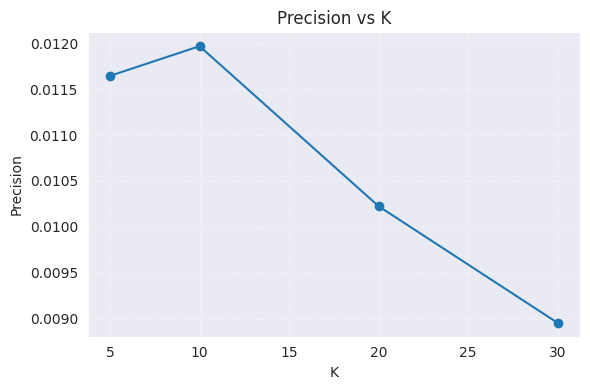

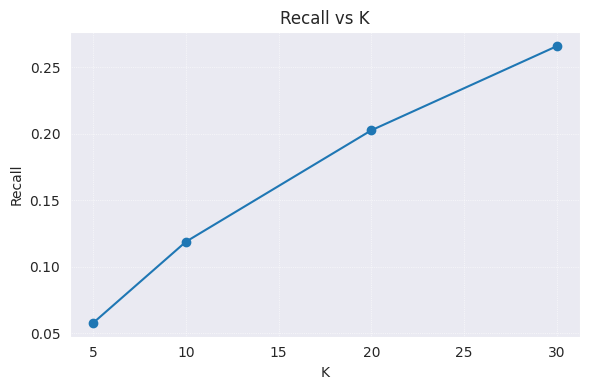

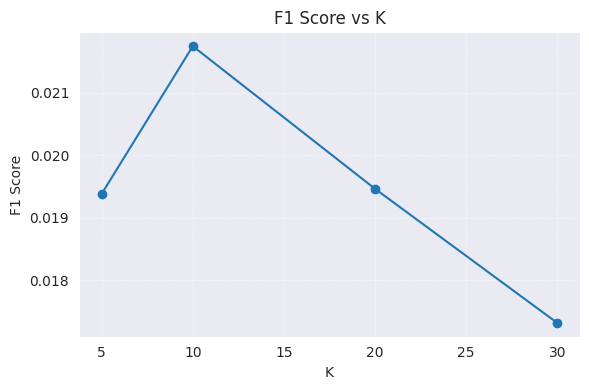

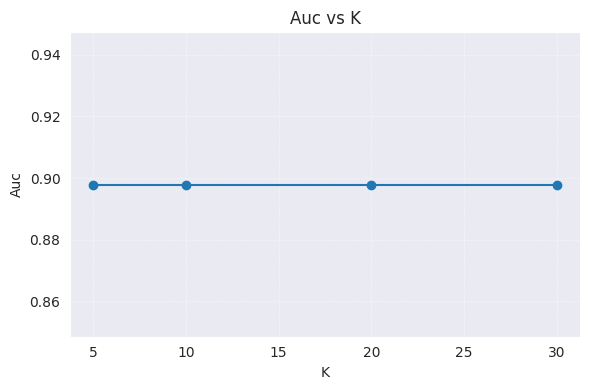

In [67]:
import matplotlib.pyplot as plt
import pandas as pd


plt.rcParams['font.family'] = 'DejaVu Sans'

# List of metrics to plot
metrics = ['precision', 'recall', 'f1_score', 'auc']

for metric in metrics:
    plt.figure(figsize=(6, 4))
    plt.plot(test_results_df['K'], test_results_df[metric], marker='o')
    plt.xlabel('K')
    # Title- and ylabel-formatting for readability
    label = metric.replace('_', ' ').title()
    plt.ylabel(label)
    plt.title(f'{label} vs K')
    plt.grid(linestyle=':', linewidth=0.5)
    plt.tight_layout()
    plt.show()


In [69]:

cold_user_inter, _ = dataset.build_interactions(
    (u, i)
    for u, i in zip(
        cold_user_df['user_id'],
        cold_user_df['app_id']
    )
)



In [70]:
# Choose the cut‑offs you care about
Ks = [5, 10, 20, 30]

# Compute metrics for each K
cold_user_results = []
for K in Ks:
    prec = precision_at_k(final_model,
                          cold_user_inter,
                          item_features=item_features,
                          k=K).mean()
    rec  = recall_at_k   (final_model,
                          cold_user_inter,
                          item_features=item_features,
                          k=K).mean()
    f1_score = np.where(
    (prec + rec) > 0,
    2 * prec * rec / (prec + rec),
    0.0)
    cold_user_results.append({
        'K': K,
        'precision': prec,
        'recall':    rec,
        'f1_score': f1_score
    })



# Compute AUC (independent of K)
auc = auc_score(final_model,
                cold_user_inter,
                item_features=item_features).mean()


# Tabulate
cold_user_results_df = pd.DataFrame(cold_user_results)
cold_user_results_df['auc'] = auc  # same AUC for every row, or move it out separately

print("Test-set performance:")
print(cold_user_results_df)
print(f"\nOverall AUC: {auc:.4f}")


Test-set performance:
    K  precision    recall              f1_score       auc
0   5   0.016400  0.066139  0.026283436398752587  0.931977
1  10   0.016663  0.138912  0.029756105230915007  0.931977
2  20   0.015179  0.256956   0.02866432311450221  0.931977
3  30   0.013437  0.339969  0.025851529671642944  0.931977

Overall AUC: 0.9320


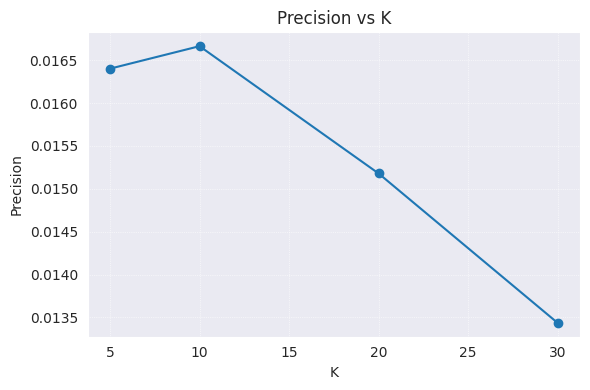

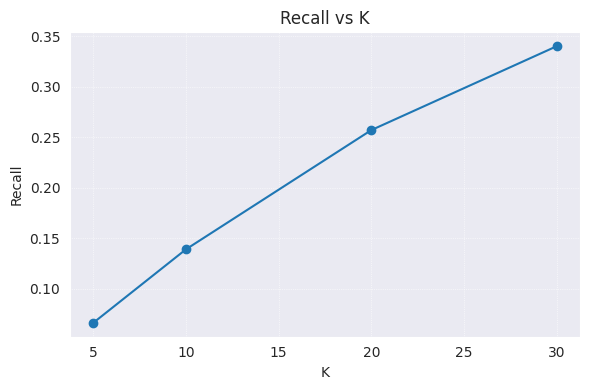

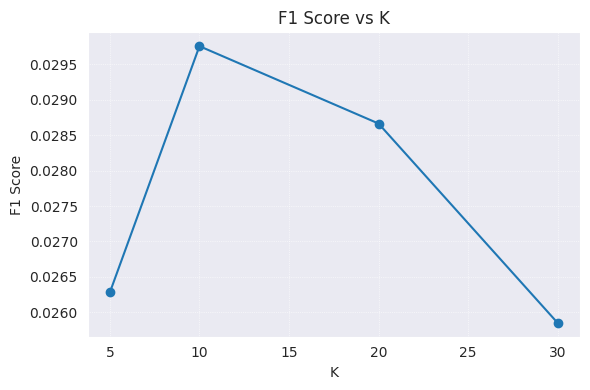

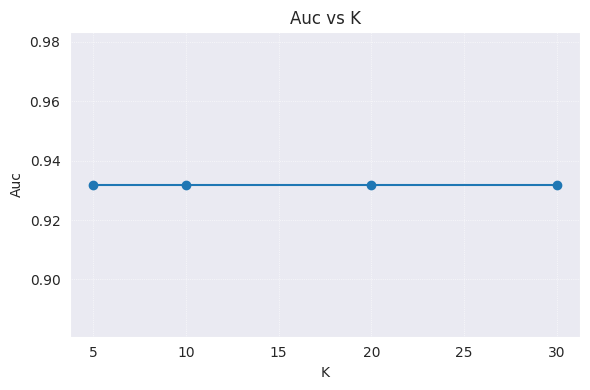

In [71]:
import matplotlib.pyplot as plt
import pandas as pd


plt.rcParams['font.family'] = 'DejaVu Sans'

# List of metrics to plot
metrics = ['precision', 'recall', 'f1_score', 'auc']

for metric in metrics:
    plt.figure(figsize=(6, 4))
    plt.plot(cold_user_results_df['K'], cold_user_results_df[metric], marker='o')
    plt.xlabel('K')
    # Title- and ylabel-formatting for readability
    label = metric.replace('_', ' ').title()
    plt.ylabel(label)
    plt.title(f'{label} vs K')
    plt.grid(linestyle=':', linewidth=0.5)
    plt.tight_layout()
    plt.show()
